In [18]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
import scipy.stats as stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

In [19]:
df = pd.read_csv("/Users/josiah/DTSC 2301/Flight Data/12683453/flights.csv")

/var/folders/yv/7g7fhntn0bddq69knwx72gj80000gn/T/ipykernel_20972/2435915714.py:1: DtypeWarning: Columns (0: altitude) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/Users/josiah/DTSC 2301/Flight Data/12683453/flights.csv")


In [20]:
missing = df.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0] if missing.any() else "No missing values found")

Missing values per column:
No missing values found


In [21]:
df = df[df["route"] == "R1"]
df["altitude"] = pd.to_numeric(df["altitude"])
print(df["flight"].nunique(), "flights")

182 flights


In [22]:
df = df.sort_values(["flight", "time"])

# Power (watts) at each reading
df["power_W"] = df["battery_voltage"] * df["battery_current"]

# Seconds between readings within each flight
df["dt"] = df.groupby("flight")["time"].diff().fillna(0)

# Energy per reading (joules). battery voltage x battery current x time step (for each sensor reading)
df["energy_J"] = df["power_W"] * df["dt"]

# Collapse to one row per flight. The data is measured in seconds so we divide energy_j by 3600 to get watt hours
flights = df.groupby("flight").agg(
    energy_Wh=("energy_J", lambda x: x.sum() / 3600),
    speed=("speed", "first"),
    payload=("payload", "first"),
    altitude=("altitude", "first"),
    mean_wind=("wind_speed", "mean"),
).reset_index()

flights.head()

,flight,energy_Wh,speed,payload,altitude,mean_wind
0,8,21.933690,4.0,0.0,25,2.914185
1,10,16.528655,6.0,0.0,25,5.111714
2,12,13.011607,10.0,0.0,25,5.998581
3,14,14.199480,12.0,250.0,25,6.228249
4,15,14.239125,10.0,250.0,25,5.532143


In [23]:
flights.describe()

,flight,energy_Wh,speed,payload,altitude,mean_wind
count,182.000000,182.000000,182.000000,182.000000,182.000000,182.000000
mean,159.120879,21.200278,8.076923,259.615385,62.500000,4.533689
std,65.770543,4.814393,2.831281,207.533171,27.904484,0.848055
min,8.000000,13.011607,4.000000,0.000000,25.000000,2.566423
25%,112.250000,17.554381,6.000000,0.000000,50.000000,3.934096
50%,159.500000,20.801324,8.000000,250.000000,62.500000,4.396080
75%,205.750000,24.580899,10.000000,500.000000,75.000000,5.100019
max,277.000000,36.225395,12.000000,750.000000,100.000000,6.670192


In [24]:
#remove outlier of weight 750, there is only 1 observation. Not enough for the model to learn from it.
flights = flights[flights["payload"] != 750]
print(flights)

     flight  energy_Wh  speed  payload  altitude  mean_wind
0         8  21.933690    4.0      0.0        25   2.914185
1        10  16.528655    6.0      0.0        25   5.111714
2        12  13.011607   10.0      0.0        25   5.998581
3        14  14.199480   12.0    250.0        25   6.228249
4        15  14.239125   10.0    250.0        25   5.532143
..      ...        ...    ...      ...       ...        ...
177     264  24.931198    6.0    250.0       100   3.439538
178     267  16.646359    8.0    500.0        25   5.058375
179     275  16.295811    8.0    500.0        25   4.139878
180     276  15.392088   10.0    500.0        25   4.392581
181     277  15.531389   10.0    500.0        25   5.524651

[181 rows x 6 columns]


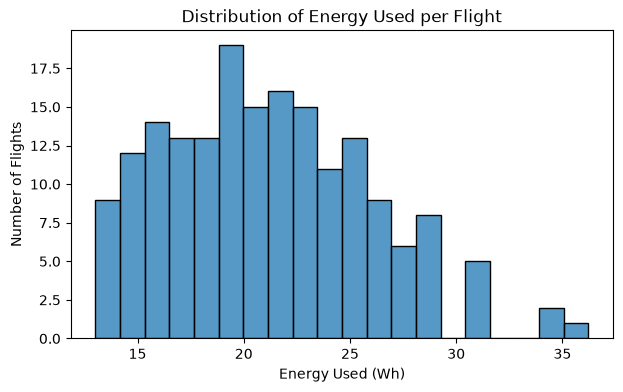

In [25]:
plt.figure(figsize=(7, 4))
sns.histplot(flights["energy_Wh"], bins=20)
plt.title("Distribution of Energy Used per Flight")
plt.xlabel("Energy Used (Wh)")
plt.ylabel("Number of Flights")
plt.show()

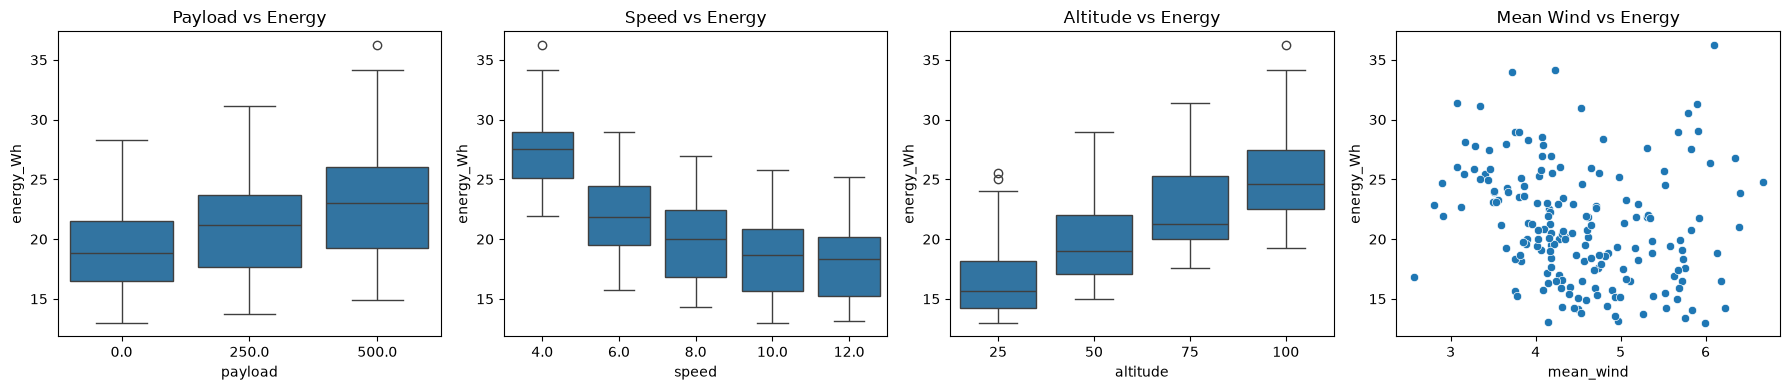

In [26]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

sns.boxplot(data=flights, x="payload", y="energy_Wh", ax=axes[0])
axes[0].set_title("Payload vs Energy")

sns.boxplot(data=flights, x="speed", y="energy_Wh", ax=axes[1])
axes[1].set_title("Speed vs Energy")

sns.boxplot(data=flights, x="altitude", y="energy_Wh", ax=axes[2])
axes[2].set_title("Altitude vs Energy")

sns.scatterplot(data=flights, x="mean_wind", y="energy_Wh", ax=axes[3])
axes[3].set_title("Mean Wind vs Energy")

plt.tight_layout()
plt.show()

In [27]:
X = flights[["speed", "payload", "altitude", "mean_wind"]]   # features
y = flights["energy_Wh"]                                     # target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(len(X_train), "training flights,", len(X_test), "test flights")

144 training flights, 37 test flights


In [28]:
baseline_pred = [y_train.mean()] * len(y_test)
baseline_mae = mean_absolute_error(y_test, baseline_pred)
print("Baseline MAE:", round(baseline_mae, 2), "Wh")

Baseline MAE: 3.72 Wh


In [31]:
lr = LinearRegression()
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("Linear Regression Mean:", round(mean_absolute_error(y_test, lr_pred), 2), "Wh")
print("Linear Regression R²:", round(r2_score(y_test, lr_pred), 3))

Linear Regression Mean: 1.3 Wh
Linear Regression R²: 0.895


In [30]:
coefs = pd.DataFrame({"feature": X.columns, "coefficient": lr.coef_})
print(coefs)
print("Intercept:", round(lr.intercept_, 2))

     feature  coefficient
0      speed    -1.017191
1    payload     0.008258
2   altitude     0.111732
3  mean_wind     0.025653
Intercept: 20.19
